In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import make_scorer
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import glob 


from sklearn import datasets, ensemble
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split

from sklearn.utils import class_weight
import json

import xgboost as xgb
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import shap

/glade/work/jhayron/conda-envs/pytorch_wr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
def brier_multi(targets, probs):
    return np.mean(np.sum((probs - targets)**2, axis=1))

In [12]:
dic_metrics_control = {}
dfs_results_control = {}
dfs_probs_control = {}

metrics_control = []

for week_out in range(1,9):
    week_out_str = f'week{week_out}'
    dic_metrics_control[week_out] = np.load(f'ResultsControl/{week_out_str}_metrics_iterations.npy')
    dfs_results_control[week_out] = pd.read_csv(f'ResultsControl/{week_out_str}_df_results.csv',index_col=0,parse_dates = True)
    dfs_probs_control[week_out] = pd.read_csv(f'ResultsControl/{week_out_str}_df_probabilities.csv',index_col=0,parse_dates = True)

    preds = dfs_probs_control[week_out]
    targets = dfs_results_control[week_out]['y_true']
    y_one_hot = np.eye(5)[targets.values.astype(int)]
    f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
    f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
    f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
    brier_score = brier_multi(y_one_hot, preds)
    
    scores_temp = [f1_score_micro,f1_score_macro,f1_score_weighted,brier_score]

    metrics_control.append(scores_temp)

metrics_control = np.array(metrics_control)

In [23]:
dic_metrics_xai = {}
dfs_results_xai = {}
dfs_probs_xai = {}

metrics_xai = []

for week_out in range(1,9):
    week_out_str = f'week{week_out}'
    dic_metrics_xai[week_out] = np.load(f'ResultsXAI_Informed//{week_out_str}_metrics_iterations.npy')
    dfs_results_xai[week_out] = pd.read_csv(f'ResultsXAI_Informed/{week_out_str}_df_results.csv',index_col=0,parse_dates = True)
    dfs_probs_xai[week_out] = pd.read_csv(f'ResultsXAI_Informed/{week_out_str}_df_probabilities.csv',index_col=0,parse_dates = True)

    preds = dfs_probs_xai[week_out]
    targets = dfs_results_xai[week_out]['y_true']
    y_one_hot = np.eye(5)[targets.values.astype(int)]
    f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
    f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
    f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
    brier_score = brier_multi(y_one_hot, preds)
    
    scores_temp = [f1_score_micro,f1_score_macro,f1_score_weighted,brier_score]

    metrics_xai.append(scores_temp)

metrics_xai = np.array(metrics_xai)

In [15]:
weeks = np.arange(1,9)

In [38]:
p05 = np.array([np.quantile(dic_metrics_control[week_out],0.05,axis=0) for week_out in weeks])
p95 = np.array([np.quantile(dic_metrics_control[week_out],0.95,axis=0) for week_out in weeks])

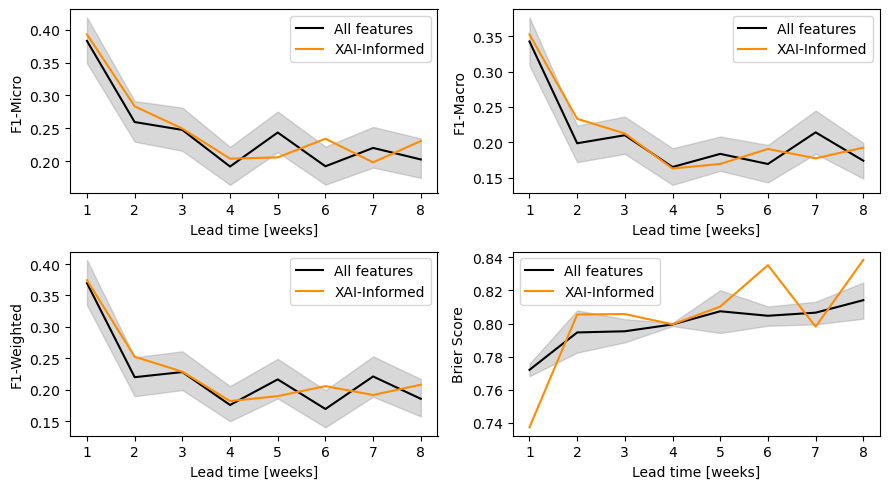

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(9,5))

axes[0,0].plot(weeks,metrics_control[:,0],color='k',label='All features')
axes[0,0].plot(weeks,metrics_xai[:,0],color='darkorange',label='XAI-Informed')
axes[0,0].fill_between(weeks,
                       p05[:,0],
                       p95[:,0],
                       color='gray',alpha=0.3,
                      )
axes[0,0].set_xlabel('Lead time [weeks]')
axes[0,0].set_ylabel('F1-Micro')
axes[0,0].legend()

axes[0,1].plot(weeks,metrics_control[:,1],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[0,1].plot(weeks,metrics_xai[:,1],color='darkorange',label='XAI-Informed')
axes[0,1].fill_between(weeks,
                       p05[:,1],
                       p95[:,1],
                       color='gray',alpha=0.3,
                      )
axes[0,1].set_xlabel('Lead time [weeks]')
axes[0,1].set_ylabel('F1-Macro')
axes[0,1].legend()

axes[1,0].plot(weeks,metrics_control[:,2],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[1,0].plot(weeks,metrics_xai[:,2],color='darkorange',label='XAI-Informed')
axes[1,0].fill_between(weeks,
                       p05[:,2],
                       p95[:,2],
                       color='gray',alpha=0.3,
                      )
axes[1,0].set_xlabel('Lead time [weeks]')
axes[1,0].set_ylabel('F1-Weighted')
axes[1,0].legend()

axes[1,1].plot(weeks,metrics_control[:,3],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[1,1].plot(weeks,metrics_xai[:,3],color='darkorange',label='XAI-Informed')
axes[1,1].fill_between(weeks,
                       p05[:,3],
                       p95[:,3],
                       color='gray',alpha=0.3,
                      )
axes[1,1].set_xlabel('Lead time [weeks]')
axes[1,1].set_ylabel('Brier Score')
axes[1,1].legend()

plt.tight_layout()
# plt.savefig(f'{path_figures}DBI.png',bbox_inches='tight')

# Confidence of results

In [111]:
scores_confident = []
for week_out in range(1,9):
    th = 0.8
    df_probs_temp = dfs_probs_control[week_out]
    df_results_temp = dfs_results_control[week_out]
    probs_predictions = np.array([df_probs_temp.values[i,df_results_temp.y_predicted.values.astype(int)[i]] for i in range(len(df_probs_temp))])
    th_predictions = np.array([df_probs_temp.quantile(th,axis=0).values[df_results_temp.y_predicted.values.astype(int)[i]] for i in range(len(df_probs_temp))])
    where_confident = np.where(probs_predictions>th_predictions)[0]
    
    df_results_confident = df_results_temp.iloc[where_confident]
    df_probs_confident = dfs_probs_control[week_out].iloc[where_confident]
    
    preds = df_probs_confident
    targets = df_results_confident['y_true']
    y_one_hot = np.eye(5)[targets.values.astype(int)]
    f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
    f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
    f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
    brier_score = brier_multi(y_one_hot, preds)
    
    scores_temp = [f1_score_micro,f1_score_macro,f1_score_weighted,brier_score]
    scores_confident.append(scores_temp)

scores_confident = np.array(scores_confident)

In [116]:
scores_confident_xai = []
for week_out in range(1,9):
    th = 0.8
    df_probs_temp = dfs_probs_xai[week_out]
    df_results_temp = dfs_results_xai[week_out]
    probs_predictions = np.array([df_probs_temp.values[i,df_results_temp.y_predicted.values.astype(int)[i]] for i in range(len(df_probs_temp))])
    th_predictions = np.array([df_probs_temp.quantile(th,axis=0).values[df_results_temp.y_predicted.values.astype(int)[i]] for i in range(len(df_probs_temp))])
    where_confident = np.where(probs_predictions>th_predictions)[0]
    
    df_results_confident = df_results_temp.iloc[where_confident]
    df_probs_confident = dfs_probs_xai[week_out].iloc[where_confident]
    
    preds = df_probs_confident
    targets = df_results_confident['y_true']
    y_one_hot = np.eye(5)[targets.values.astype(int)]
    f1_score_micro = f1_score(targets, np.argmax(preds, axis=1), average='micro')  # Use your chosen metric
    f1_score_macro = f1_score(targets, np.argmax(preds, axis=1), average='macro')  # Use your chosen metric
    f1_score_weighted = f1_score(targets, np.argmax(preds, axis=1), average='weighted')  # Use your chosen metric
    brier_score = brier_multi(y_one_hot, preds)
    
    scores_temp = [f1_score_micro,f1_score_macro,f1_score_weighted,brier_score]
    scores_confident_xai.append(scores_temp)

scores_confident_xai = np.array(scores_confident_xai)

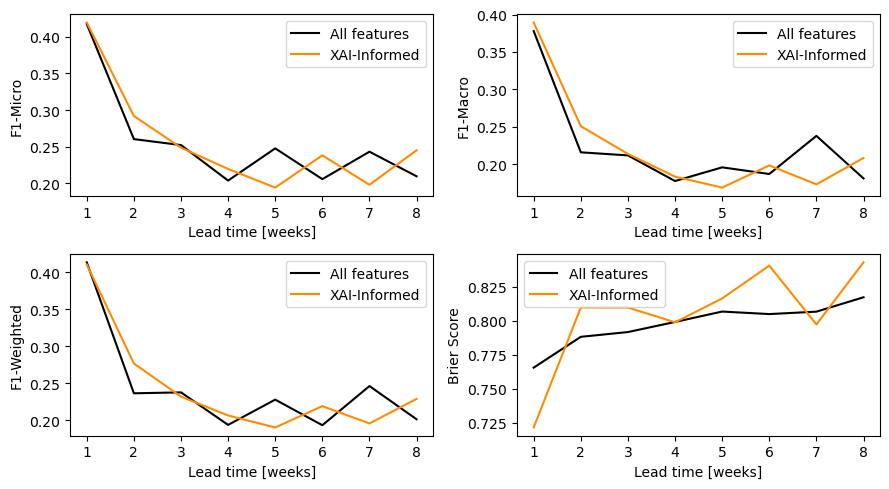

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(9,5))

axes[0,0].plot(weeks,scores_confident[:,0],color='k',label='All features')
axes[0,0].plot(weeks,scores_confident_xai[:,0],color='darkorange',label='XAI-Informed')

axes[0,0].set_xlabel('Lead time [weeks]')
axes[0,0].set_ylabel('F1-Micro')
axes[0,0].legend()

axes[0,1].plot(weeks,scores_confident[:,1],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[0,1].plot(weeks,scores_confident_xai[:,1],color='darkorange',label='XAI-Informed')
# axes[0,1].fill_between(weeks,
#                        p05[:,1],
#                        p95[:,1],
#                        color='gray',alpha=0.3,
#                       )
axes[0,1].set_xlabel('Lead time [weeks]')
axes[0,1].set_ylabel('F1-Macro')
axes[0,1].legend()

axes[1,0].plot(weeks,scores_confident[:,2],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[1,0].plot(weeks,scores_confident_xai[:,2],color='darkorange',label='XAI-Informed')
# axes[1,0].fill_between(weeks,
#                        p05[:,2],
#                        p95[:,2],
#                        color='gray',alpha=0.3,
#                       )
axes[1,0].set_xlabel('Lead time [weeks]')
axes[1,0].set_ylabel('F1-Weighted')
axes[1,0].legend()

axes[1,1].plot(weeks,scores_confident[:,3],color='k',label='All features')# axes[1].set_xlabel('Number of clusters (k)')
axes[1,1].plot(weeks,scores_confident_xai[:,3],color='darkorange',label='XAI-Informed')
# axes[1,1].fill_between(weeks,
#                        p05[:,3],
#                        p95[:,3],
#                        color='gray',alpha=0.3,
#                       )
axes[1,1].set_xlabel('Lead time [weeks]')
axes[1,1].set_ylabel('Brier Score')
axes[1,1].legend()

plt.tight_layout()
# plt.savefig(f'{path_figures}DBI.png',bbox_inches='tight')